# 02 - Bias and Fairness Analysis

**NovaCred Credit Application Governance Analysis**

This notebook documents the bias and fairness assessment of the cleaned credit
applications dataset. We systematically evaluate potential disparities in loan
approval outcomes across protected and related attributes, focusing on
**gender bias**, **age-based discrimination**, and **proxy discrimination**.

The analysis includes the computation of **fairness metrics** (such as the
Disparate Impact Ratio), **statistical significance testing**, and exploratory
analysis of **interaction effects** between demographic attributes.
The goal is to identify whether the credit approval process exhibits patterns
that may indicate unfair or discriminatory outcomes.

## 1. Imports & Load Data 

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats
from dateutil import parser as date_parser


df = pd.read_csv("../data/cleaned_credit_applications.csv")
df.shape, df.columns.tolist()

((500, 29),
 ['app_id',
  'full_name',
  'email',
  'ssn',
  'ip_address',
  'gender',
  'date_of_birth',
  'zip_code',
  'annual_income',
  'credit_history_months',
  'debt_to_income',
  'savings_balance',
  'spending_total',
  'spending_categories',
  'spending_category_list',
  'loan_approved',
  'interest_rate',
  'approved_amount',
  'rejection_reason',
  'processing_timestamp',
  'loan_purpose',
  'notes',
  'gender_original',
  'date_of_birth_original',
  'high_dti_flag',
  'email_valid',
  'completeness_score',
  'completeness_pct',
  'ssn_duplicate_flag'])

## 2. Outcome And Age Variable Calculation

In this section, we prepare key variables required for the bias and fairness analysis. 
Specifically, we construct the binary **loan approval outcome** used throughout the analysis 
and derive an **age variable** from the applicants' date of birth. 

To facilitate fairness assessments, applicants are additionally grouped into **age categories**, 
allowing us to evaluate potential disparities in loan approval outcomes across demographic groups. 
These variables serve as the basis for subsequent fairness metrics, statistical testing, 
and bias analysis.

### 2.1 Define Loan Approval Outcome

In [25]:
# Outcome
df["loan_approved"] = df["loan_approved"].astype(bool)

### 2.2 Compute Applicant Age

In [27]:
# Age from date_of_birth (cleaning notebook already parsed dates at some point, but CSV may store as string)
df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], errors="coerce")

today = pd.Timestamp("today").normalize()
df["age"] = ((today - df["date_of_birth"]).dt.days / 365.25).round(1)

### 2.3 Create Age Groups

In [29]:
# Age groups (feel free to tweak bins after you look at distribution)
bins = [0, 29, 44, 59, 120]
labels = ["<30", "30–44", "45–59", "60+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

### 2.4 Age Distribution Histogram

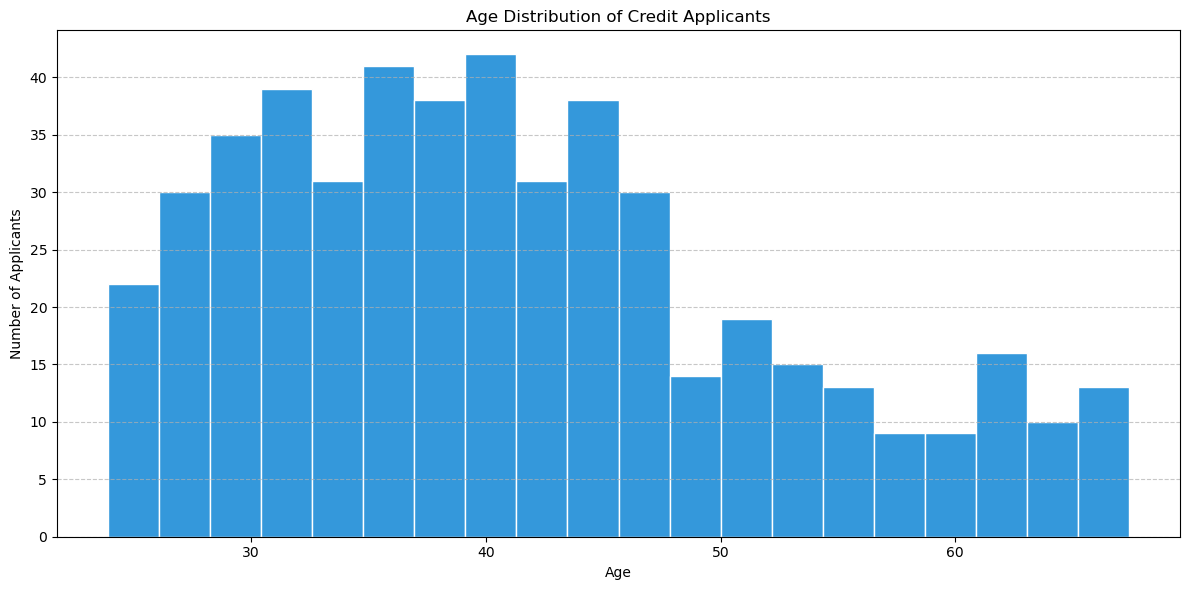

In [23]:
# Age distribution visualization (consistent style with Data Quality notebook)

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df_main["age"], bins=20, color="#3498db", edgecolor="white")

ax.set_title("Age Distribution of Credit Applicants")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Applicants")

# add gridlines like in the data quality notebook
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()